<a href="https://colab.research.google.com/github/zilbersm/ZilbersteinM_Neur265/blob/main/homework/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maya Zilberstein

*Introduction to Neural Data Analysis (Neur 265)*

**02/12/2026**


In [1]:
#Imports python libraries

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
#Imports url
url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'

#Reads the data set using pandas, and then saves it as patch_seq.
patch_seq = pd.read_csv(url)

Text(0.5, 1.0, 'Value Counts of Markers in patch_seq')

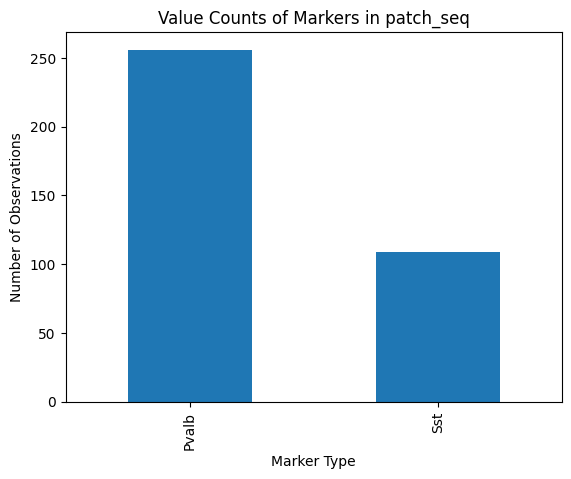

In [3]:
#Plots a bar graph that shows the value counts from the "Marker" column of the patch_seq data.
patch_seq['Marker'].value_counts().plot(kind='bar')

#Label axes
plt.xlabel('Marker Type')
plt.ylabel('Number of Observations')
plt.title('Value Counts of Markers in patch_seq')

Text(0.5, 1.0, 'Distribution of Markers in patch_seq')

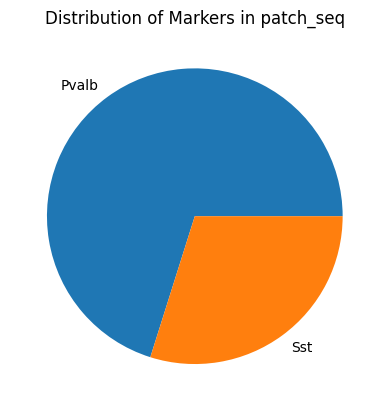

In [13]:
#Plots a pie chart that shows the value counts from the "Marker" column of the patch_seq data.
patch_seq['Marker'].value_counts().plot(kind='pie')

#Graph title and removed y-label
plt.ylabel('')
plt.title('Distribution of Markers in patch_seq')

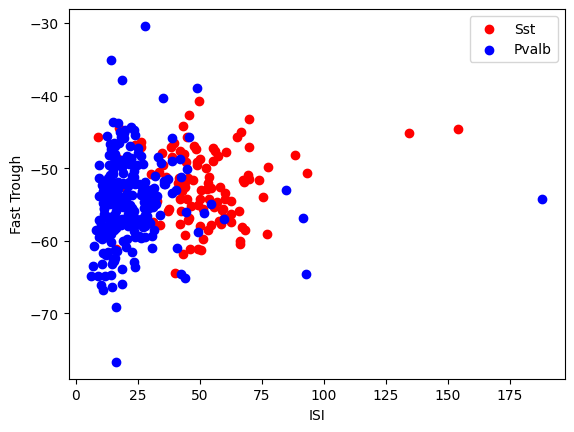

In [32]:
#Checks the length of the data set
length = len(patch_seq)

#Set booleans for legend
sst_labeled = False
pvalb_labeled = False

#Loops through the patch_seq data and plots the scatter plot with the "ISI" value on the x-axis and the "Fast_Trough" values on the y-axis. This data will be color coded with Sst neurons being red and Pvalb neurons blue.
for i in range(length) :
  row = patch_seq.iloc[i]
  if row['Marker'] == 'Sst' :
    if not sst_labeled :
      lblSst = 'Sst'
    else :
      lblSst = ''
    plt.scatter(row['ISI'], row['Fast_Trough'], color = 'red', label = lblSst)
    sst_labeled = True
  elif row['Marker'] == 'Pvalb' :
    if not pvalb_labeled :
      lblPvalb = 'Pvalb'
    else :
      lblPvalb = ''
    plt.scatter(row['ISI'], row['Fast_Trough'], color = 'blue', label = lblPvalb)
    pvalb_labeled = True

#Labels axes of the scatter plot
plt.xlabel('ISI')
plt.ylabel('Fast Trough')
plt.legend(loc='best')

plt.show()

In [33]:
#Define a function that, when called upon, executes the code in the previous code cell
def patchScatter():
  #Checks the length of the data set
  length = len(patch_seq)

  #Set booleans for legend
  sst_labeled = False
  pvalb_labeled = False

  #Loops through the patch_seq data and plots the scatter plot with the "ISI" value on the x-axis and the "Fast_Trough" values on the y-axis. This data will be color coded with Sst neurons being red and Pvalb neurons blue.
  for i in range(length) :
    row = patch_seq.iloc[i]
    if row['Marker'] == 'Sst' :
      if not sst_labeled :
        lblSst = 'Sst'
      else :
        lblSst = ''
      plt.scatter(row['ISI'], row['Fast_Trough'], color = 'red', label = lblSst)
      sst_labeled = True
    elif row['Marker'] == 'Pvalb' :
      if not pvalb_labeled :
        lblPvalb = 'Pvalb'
      else :
        lblPvalb = ''
      plt.scatter(row['ISI'], row['Fast_Trough'], color = 'blue', label = lblPvalb)
      pvalb_labeled = True

  #Labels axes of the scatter plot
  plt.xlabel('ISI')
  plt.ylabel('Fast Trough')
  plt.legend(loc='best')

  plt.show()

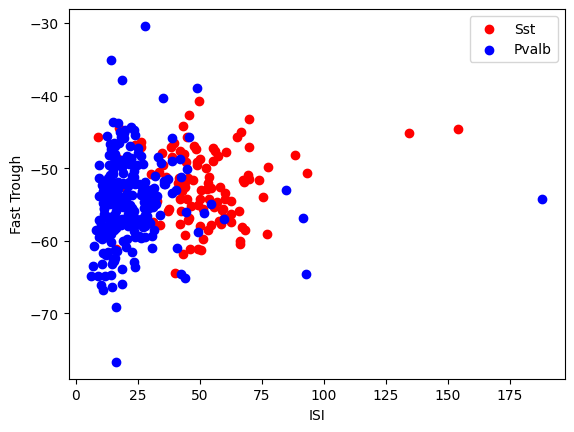

In [34]:
#Calls the patchScatter() function
patchScatter()

In [35]:
#Return the mean, standard deviation, and range of the "Fast_Trough" column for "Sst" neurons and "Pvalb" neurons through the pandas describe function.
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


The analysis of the Fast Trough values between the two neuron types showed that the Pvalb neurons have a more negative fast trough mean (-54.55mV) than the Sst neurons (-52.51mV).

This means that the Pvalb group has a more negative undershoot, which indicates that the membrane potential in Pvalb neurons drops further during the fast trough phase compared to Sst neurons.

In [36]:
#Returns the skewness of the "Fast Trough" column for "Sst" neurons and "Pvalb" neurons.
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


The skewness values for both the Sst and Pvalb neuron groups are between -0.5 and 0.5. Therefore, both neuron groups have a normal distribution of fast trough values.

In [37]:
#Returns the skewness of the "ISI" column for "Sst" neurons and "Pvalb" neurons.
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


The skewness values for both the Sst and Pvalb neuron groups are greater than 0.5. Therefore, both neuron groups have a skewed distribution of ISI values.

In [38]:
#Isolates the two groups of neurons, and set each group as a separate variable.
sst_neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']

#Performs a t-test to see if our "Fast_Trough" values differ between "Sst" and "Pvalb" neurons.
stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

The p-value of this test is approximately 0.0017. Since this p-value is smaller than $\alpha = 0.05$, the standard significance level, we can reject the null hypothesis. So, there is a statistically significant difference in the mean undershoot voltage values between Sst and Pvalb neurons.

In [41]:
#Creates variables with all missing values deleted.
sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()

#Performs a t-test to see if our "ISI" values differ between "Sst" and "Pvalb" neurons.
stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

The p-value of this test is approximately 0.2.69. Since this p-value is greater than $\alpha = 0.05$, the standard significance level, we can NOT reject the null hypothesis. So, there is NO statistically significant difference in the mean ISI values between Sst and Pvalb neurons.